Importing libraries

In [2]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score
import itertools
import warnings
warnings.filterwarnings("ignore")

**Stage 1**

Standard configuration parameters

In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE

RUN_FULL_DATASET = False

Loading dataset

In [8]:
!pip install -q gdown
import gdown

file_id = '1AGDniD9kkFclMD60VT0Nba8-eAKnPDWT'
url = f'https://drive.google.com/uc?id={file_id}'

gdown.download(url, '/content/archive.zip', quiet=False)

!unzip -q "/content/archive.zip" -d /content/chest_xray_data
print(os.listdir('/content/chest_xray_data'))

Downloading...
From (original): https://drive.google.com/uc?id=1AGDniD9kkFclMD60VT0Nba8-eAKnPDWT
From (redirected): https://drive.google.com/uc?id=1AGDniD9kkFclMD60VT0Nba8-eAKnPDWT&confirm=t&uuid=e7304da2-088b-4aff-8737-616e9192dc0b
To: /content/archive.zip
100%|██████████| 1.79G/1.79G [00:17<00:00, 101MB/s]


replace /content/chest_xray_data/test/NORMAL/IM-0006-0001.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ['val', 'train', 'test']


Splitting dataset by categories: train, validation, test files

In [7]:
train_dt = tf.keras.utils.image_dataset_from_directory(
    '/content/chest_xray_data/train',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_dt = tf.keras.utils.image_dataset_from_directory(
    '/content/chest_xray_data/val',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_dt = tf.keras.utils.image_dataset_from_directory(
    '/content/chest_xray_data/test',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

if not RUN_FULL_DATASET:
    print("Training on a fast, downsampled dataset.")
    train_dt = train_dt.take(15)
    val_dt = val_dt.take(5)
else:
    print("Training on the FULL dataset.")

train_dt = train_dt.prefetch(buffer_size=AUTOTUNE)
val_dt = val_dt.prefetch(buffer_size=AUTOTUNE)
test_dt = test_dt.prefetch(buffer_size=AUTOTUNE)

Found 6800 files belonging to 2 classes.
Found 1700 files belonging to 2 classes.
Found 30 files belonging to 2 classes.
Training on a fast, downsampled dataset.


Class size distribution (Normal vs. Pneumonia)

In [10]:
base_path = '/content/chest_xray_data'
splits = ['train', 'val', 'test']
distribution_data = []

for split in splits:
    split_path = os.path.join(base_path, split)
    if os.path.exists(split_path):
        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)
            if os.path.isdir(class_path):
                count = len(os.listdir(class_path))
                distribution_data.append({
                    "Split": split.upper(),
                    "Class": class_name,
                    "Count": count
                })

df_dist = pd.DataFrame(distribution_data)


print("Class Distributions")
print(df_dist.to_string(index=False))

Class Distributions
Split     Class  Count
TRAIN    NORMAL   3400
TRAIN PNEUMONIA   3400
  VAL    NORMAL    850
  VAL PNEUMONIA    850
 TEST    NORMAL     15
 TEST PNEUMONIA     15


Some images visualisation - to verify images are loaded in a correct way

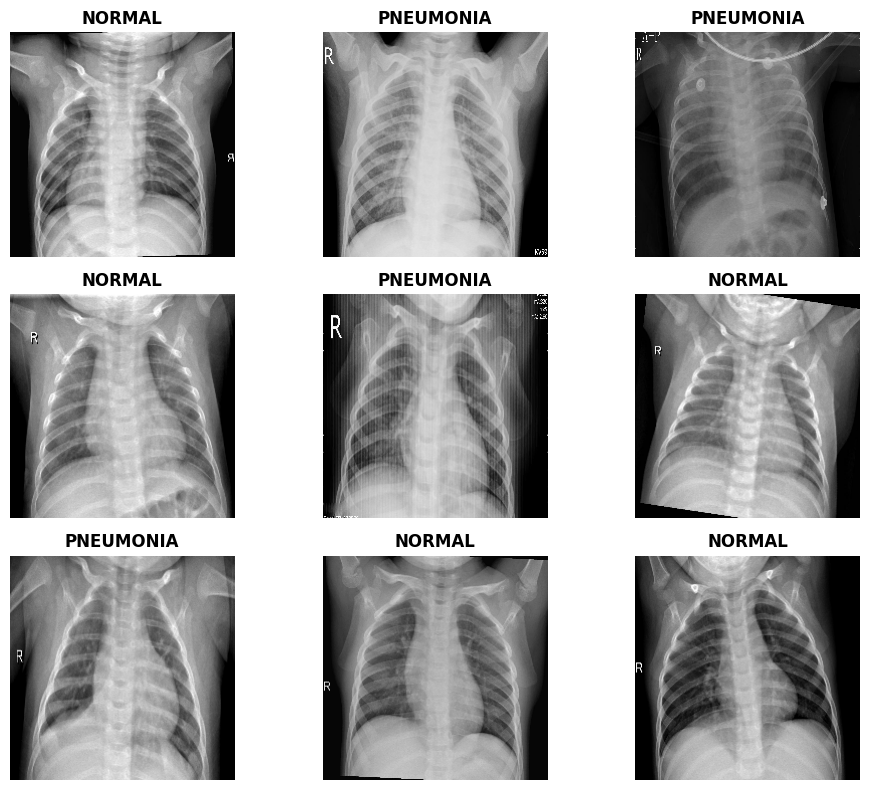

In [11]:
class_names = ['NORMAL', 'PNEUMONIA']

for images, labels in train_dt.take(1):
    plt.figure(figsize=(10, 8))

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        img_array = images[i].numpy().astype("uint8")
        plt.imshow(img_array)

        label_index = np.argmax(labels[i])
        plt.title(class_names[label_index], fontsize=12, fontweight='bold')

        plt.axis("off")

    plt.tight_layout()
    plt.show()

**Stage 2**

**Model 1: setup using MobileNetV2**  

Setting an Exponential Learning Rate Decay Schedule

In [12]:
def lr_decay(epoch):
    initial_lr = 0.001
    decay_factor = 0.7
    return initial_lr * math.pow(decay_factor, epoch)

lr_scheduler_callback = tf.keras.callbacks.LearningRateScheduler(lr_decay, verbose=1)

In [13]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Building the custom head

In [14]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')
])

Model compliation

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train function with verbose=2 and LR Scheduler

In [16]:
history = model.fit(
    train_dt,
    validation_data=val_dt,
    epochs=10,
    verbose=2,
    callbacks=[lr_scheduler_callback]
)


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/10
213/213 - 107s - 505ms/step - accuracy: 0.8831 - loss: 0.2805 - val_accuracy: 0.9082 - val_loss: 0.2543 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0007.
Epoch 2/10
213/213 - 95s - 446ms/step - accuracy: 0.9297 - loss: 0.1821 - val_accuracy: 0.9400 - val_loss: 0.1658 - learning_rate: 7.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.00049.
Epoch 3/10
213/213 - 54s - 255ms/step - accuracy: 0.9375 - loss: 0.1587 - val_accuracy: 0.9394 - val_loss: 0.1580 - learning_rate: 4.9000e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.00034299999999999993.
Epoch 4/10
213/213 - 54s - 254ms/step - accuracy: 0.9456 - loss: 0.1388 - val_accuracy: 0.9447 - val_loss: 0.1516 - learning_rate: 3.4300e-04

Epoch 5: LearningRateScheduler setting learning rate to 0.00024009999999999995.
Epoch 5/10
213/213 - 64s - 299ms/step - accuracy: 0.9487 - loss: 0.1302 - val_

 Learning curve analysis

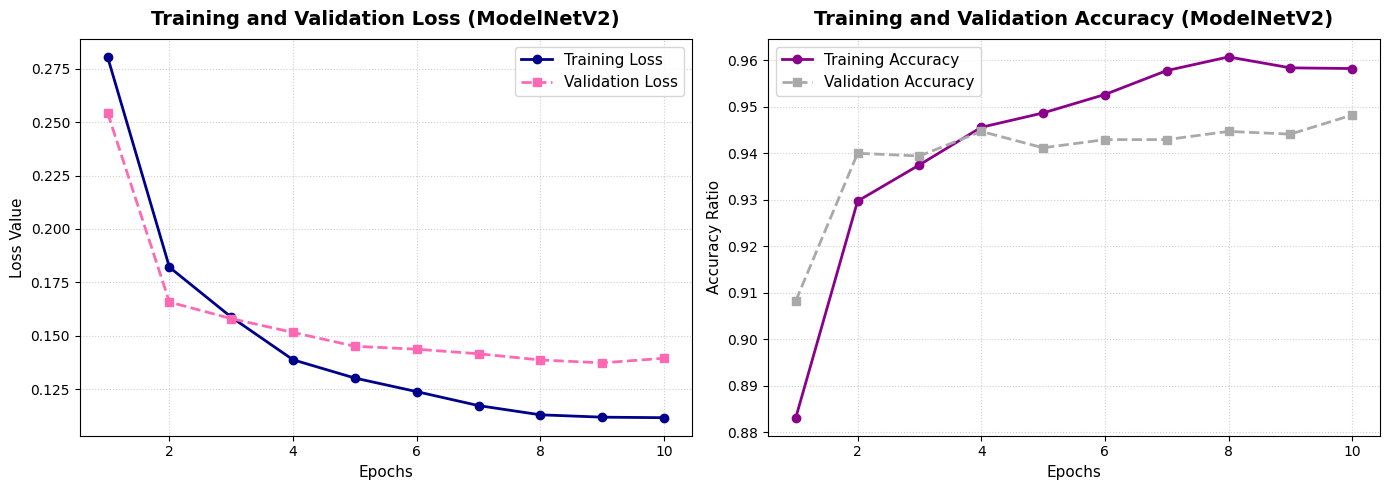

In [36]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# LOSS CURVES
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training Loss', color='darkblue', linewidth=2, marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='hotpink', linewidth=2, linestyle='--', marker='s')
plt.title('Training and Validation Loss (ModelNetV2)', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Loss Value', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

# ACCURACY CURVES
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label='Training Accuracy', color='darkmagenta', linewidth=2, marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='darkgrey', linewidth=2, linestyle='--', marker='s')
plt.title('Training and Validation Accuracy (ModelNetV2)', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Accuracy Ratio', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

Confusion Matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


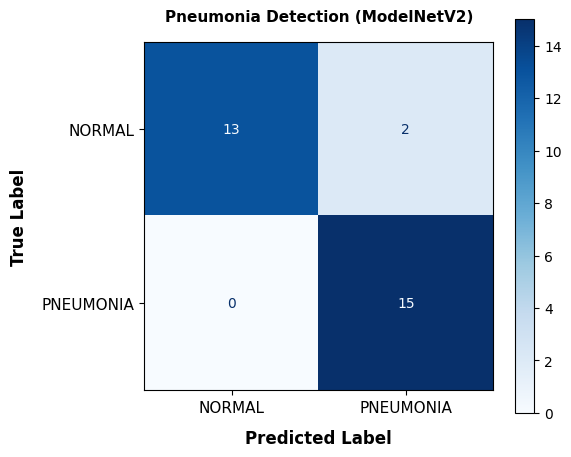

In [61]:
y_true = []
for _, labels in test_dt:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

y_pred_probs = model.predict(test_dt, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = ['NORMAL', 'PNEUMONIA']
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title('Pneumonia Detection (ModelNetV2)', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True Label', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(False)

plt.tight_layout()
plt.show()

Classification report

In [43]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      NORMAL       1.00      0.87      0.93        15
   PNEUMONIA       0.88      1.00      0.94        15

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



ROC-AUC curve plot

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step


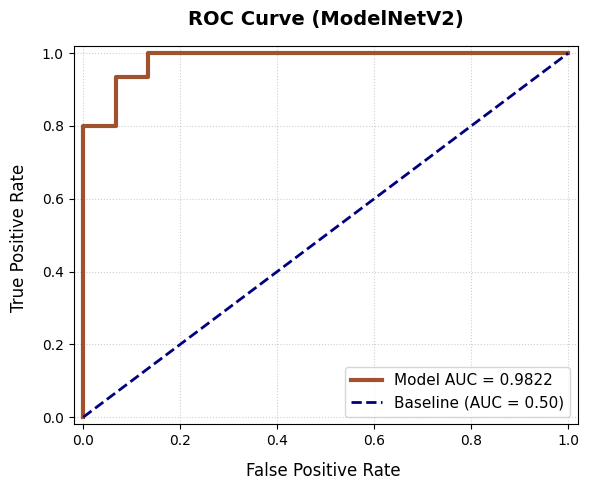

In [59]:
y_true = []
for _, labels in test_dt:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

y_pred_probs = model.predict(test_dt, verbose=1)

pneumonia_probs = y_pred_probs[:, 1]

fpr, tpr, thresholds = roc_curve(y_true, pneumonia_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='sienna', lw=3, label=f'Model AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Baseline (AUC = 0.50)')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.title('ROC Curve (ModelNetV2)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate ', fontsize=12, labelpad=10)
plt.ylabel('True Positive Rate ', fontsize=12, labelpad=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

In [53]:
print("AUC: ", roc_auc)

AUC:  0.9822222222222222


**Stage 3: CNN from scratch -- Conv2D + MaxPooling2d**

Model setup

In [24]:
from tensorflow.keras import models, layers

def build_cnn_from_scratch(input_shape=(224, 224, 3)):

    model = models.Sequential([
        layers.Rescaling(1./255, input_shape=input_shape),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(2, activation='softmax')
    ])

    return model

scratch_model = build_cnn_from_scratch()
scratch_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,452,482 (13.17 MB)

 Trainable params: 3,452,482 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
scratch_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_list = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1),
    lr_scheduler_callback
]

history_scratch = scratch_model.fit(
    train_dt,
    validation_data=val_dt,
    epochs=10,
    verbose=2,
    callbacks=callbacks_list
)


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/10
213/213 - 77s - 363ms/step - accuracy: 0.9057 - loss: 0.2261 - val_accuracy: 0.9576 - val_loss: 0.1324 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0007.
Epoch 2/10
213/213 - 60s - 283ms/step - accuracy: 0.9618 - loss: 0.1096 - val_accuracy: 0.9571 - val_loss: 0.1317 - learning_rate: 7.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.00049.
Epoch 3/10
213/213 - 92s - 433ms/step - accuracy: 0.9682 - loss: 0.0844 - val_accuracy: 0.9653 - val_loss: 0.1106 - learning_rate: 4.9000e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.00034299999999999993.
Epoch 4/10
213/213 - 73s - 343ms/step - accuracy: 0.9746 - loss: 0.0697 - val_accuracy: 0.9653 - val_loss: 0.1091 - learning_rate: 3.4300e-04

Epoch 5: LearningRateScheduler setting learning rate to 0.00024009999999999995.
Epoch 5/10
213/213 - 81s - 382ms/step - accuracy: 0.9796 - loss: 0.0549 - val_a

Accuracy and loss curve analysis

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step


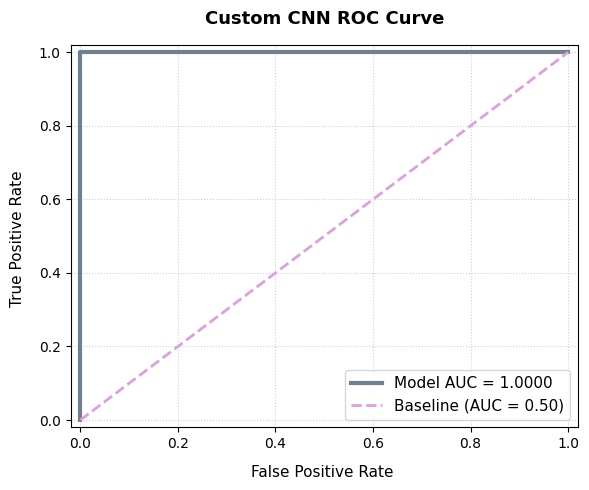

In [58]:
y_true_scratch = []
for _, labels in test_dt:
    y_true_scratch.extend(np.argmax(labels.numpy(), axis=1))
y_true_scratch = np.array(y_true_scratch)

y_pred_probs_scratch = scratch_model.predict(test_dt, verbose=1)
pneumonia_probs_scratch = y_pred_probs_scratch[:, 1]

fpr_scratch, tpr_scratch, _ = roc_curve(y_true_scratch, pneumonia_probs_scratch)
roc_auc_scratch = auc(fpr_scratch, tpr_scratch)

plt.figure(figsize=(6, 5))
plt.plot(fpr_scratch, tpr_scratch, color='slategrey', lw=3,
         label=f'Model AUC = {roc_auc_scratch:.4f}')
plt.plot([0, 1], [0, 1], color='plum', lw=2, linestyle='--',
         label='Baseline (AUC = 0.50)')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.title('Custom CNN ROC Curve', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate ', fontsize=11, labelpad=10)
plt.ylabel('True Positive Rate ', fontsize=11, labelpad=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

Confusion Matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step


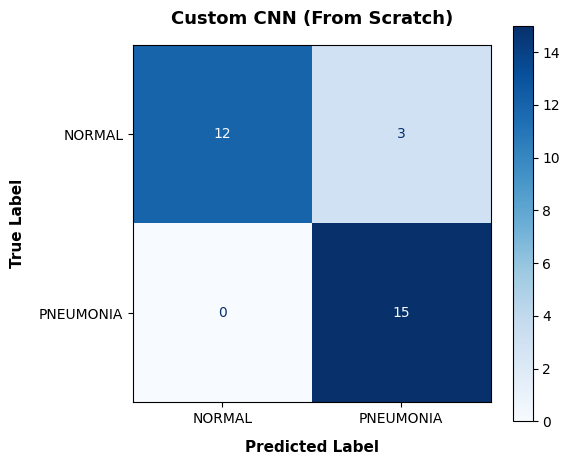

In [64]:
y_true_scratch = []
for _, labels in test_dt:
    y_true_scratch.extend(np.argmax(labels.numpy(), axis=1))
y_true_scratch = np.array(y_true_scratch)

y_pred_probs_scratch = scratch_model.predict(test_dt, verbose=1)
y_pred_scratch = np.argmax(y_pred_probs_scratch, axis=1)

class_names = ['NORMAL', 'PNEUMONIA']
cm_scratch = confusion_matrix(y_true_scratch, y_pred_scratch)

fig, ax = plt.subplots(figsize=(6, 5))
disp_scratch = ConfusionMatrixDisplay(confusion_matrix=cm_scratch, display_labels=class_names)

disp_scratch.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title('Custom CNN (From Scratch)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('True Label', fontsize=11, fontweight='bold', labelpad=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(False)

plt.tight_layout()
plt.show()

Classification report

In [69]:
y_true_scratch = []
for _, labels in test_dt:
    y_true_scratch.extend(np.argmax(labels.numpy(), axis=1))
y_true_scratch = np.array(y_true_scratch)

y_pred_probs_scratch = scratch_model.predict(test_dt, verbose=1)
y_pred_scratch = np.argmax(y_pred_probs_scratch, axis=1)

class_names = ['NORMAL', 'PNEUMONIA']
report = classification_report(y_true_scratch, y_pred_scratch, target_names=class_names, digits=4)
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step
              precision    recall  f1-score   support

      NORMAL     1.0000    0.8000    0.8889        15
   PNEUMONIA     0.8333    1.0000    0.9091        15

    accuracy                         0.9000        30
   macro avg     0.9167    0.9000    0.8990        30
weighted avg     0.9167    0.9000    0.8990        30



ROC-AUC Curve

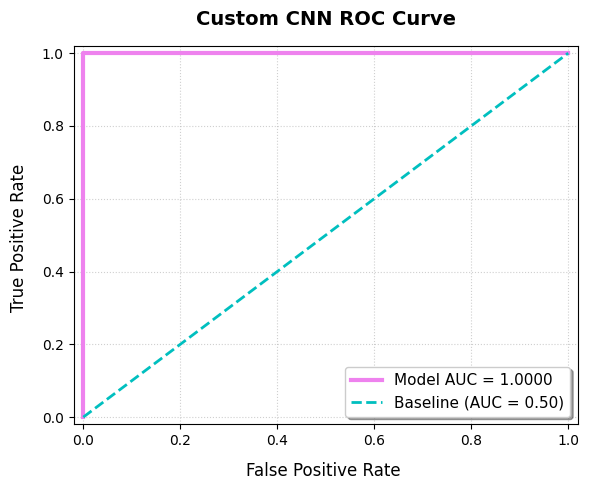

In [70]:
y_true_scratch = []
for _, labels in test_dt:
    y_true_scratch.extend(np.argmax(labels.numpy(), axis=1))
y_true_scratch = np.array(y_true_scratch)

y_probs_scratch = scratch_model.predict(test_dt, verbose=0)[:, 1]
fpr_scratch, tpr_scratch, _ = roc_curve(y_true, y_probs_scratch)
auc_scratch = auc(fpr_scratch, tpr_scratch)

class_names = ['NORMAL', 'PNEUMONIA']

plt.figure(figsize=(6, 5))

plt.plot(fpr_scratch, tpr_scratch, color='violet', lw=3,
         label=f'Model AUC = {auc_scratch:.4f}')

plt.plot([0, 1], [0, 1], color='c', lw=2, linestyle='--',
         label='Baseline (AUC = 0.50)')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.title('Custom CNN ROC Curve', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate ', fontsize=12, labelpad=10)
plt.ylabel('True Positive Rate ', fontsize=12, labelpad=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

**Stage 4: Comparing evaluation metrics. ModelNetV2 vs Custom CNN**

In [26]:
def eval_binary_model(model, dataset, model_name):
    y_true = []
    for _, labels in dataset:
        y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_true = np.array(y_true)

    y_pred_probs = model.predict(dataset, verbose=1)
    y_pred_cls1 = y_pred_probs[:, 1]
    y_pred_labels = np.argmax(y_pred_probs, axis=1)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_labels).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    auc_score = roc_auc_score(y_true, y_pred_cls1)
    recall = recall_score(y_true, y_pred_labels)
    precision = precision_score(y_true, y_pred_labels)
    f1 = f1_score(y_true, y_pred_labels)
    accuracy = np.mean(y_true == y_pred_labels)
    loss = model.evaluate(dataset, verbose=0)[0]

    return {
        "Model": model_name,
        "AUC": round(auc_score, 4),
        "Accuracy": round(accuracy, 4),
        "Loss": round(loss, 4),
        "Recall (Sens)": round(recall, 4),
        "Specificity (Spec)": round(specificity, 4),
        "Precision": round(precision, 4),
        "F1": round(f1, 4),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [31]:
results_registry = []

scratch_metrics = eval_binary_model(scratch_model, test_dt, "Custom CNN (From Scratch)")
results_registry.append(scratch_metrics)

mobilenet_metrics = eval_binary_model(model, test_dt, "MobileNetV2 (Transfer Learning)")
results_registry.append(mobilenet_metrics)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step


In [71]:
df_comparison = pd.DataFrame(results_registry)
print("\nFinal comparison between Custom CNN and Transfer Learning\n")
print(df_comparison.to_string(index=False))


Final comparison between Custom CNN and Transfer Learning

                          Model    AUC  Accuracy   Loss  Recall (Sens)  Specificity (Spec)  Precision     F1  TN  FP  FN  TP
      Custom CNN (From Scratch) 1.0000    0.9000 0.2200            1.0              0.8000     0.8333 0.9091  12   3   0  15
MobileNetV2 (Transfer Learning) 0.9822    0.9333 0.2031            1.0              0.8667     0.8824 0.9375  13   2   0  15


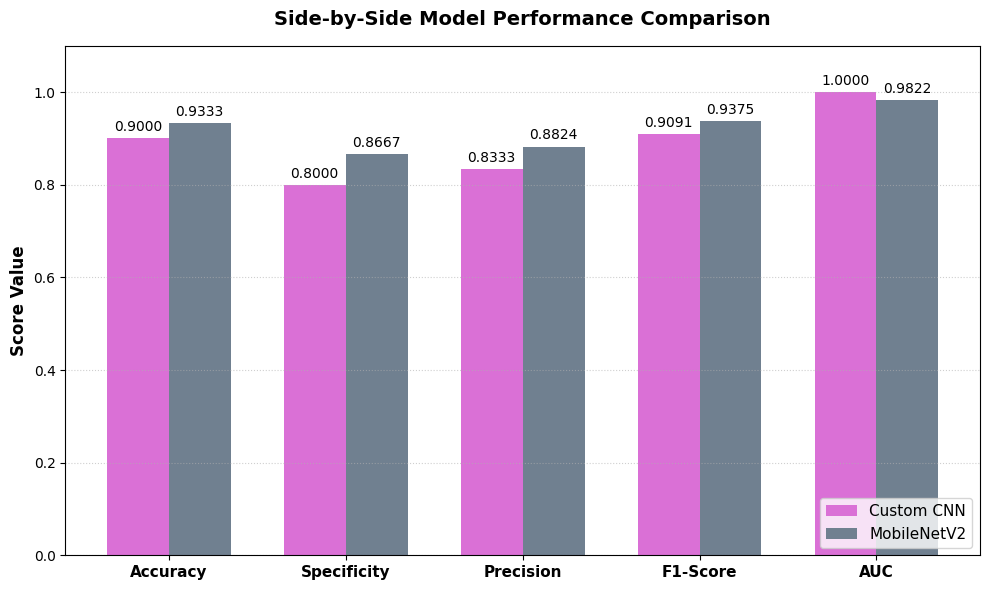

In [75]:
metrics = ['Accuracy', 'Specificity', 'Precision', 'F1-Score', 'AUC']
custom_cnn_vals = [0.9000, 0.8000, 0.8333, 0.9091, 1]
mobilenet_vals = [0.9333, 0.8667, 0.8824, 0.9375, 0.9822]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, custom_cnn_vals, width, label='Custom CNN', color='orchid')
rects2 = ax.bar(x + width/2, mobilenet_vals, width, label='MobileNetV2', color='slategrey')

ax.set_ylabel('Score Value', fontsize=12, fontweight='bold')
ax.set_title('Side-by-Side Model Performance Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', linestyle=':', alpha=0.6)


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()